# Create and visualize a normal distribution with 1000 observations


In [2]:
from numpy import random
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
normal = random.normal(size = 1000)

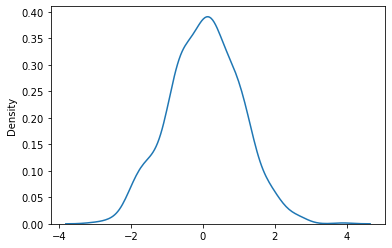

In [4]:
sns.kdeplot(random.normal(size = 1000))
plt.show()

## How many values are in the range between the mean() +- 1 std()?

- What is the expected percentage?
- Calculate the percentage in your simulated data

In [5]:
# Expected percentage: 68.2%

In [6]:
normal.mean()

-0.018678909647943175

In [7]:
normal.std()

1.0168674700908067

In [8]:
lst = []

for i in normal:
    if i < normal.mean() + normal.std() and i > normal.mean() - normal.std():
        lst.append(i)

In [9]:
# Percentage in my simulated data
len(lst) / len(normal)

0.685

## sek_sqm

In [10]:
import pandas as pd

In [11]:
df = pd.read_csv("sthlm_eng.csv")

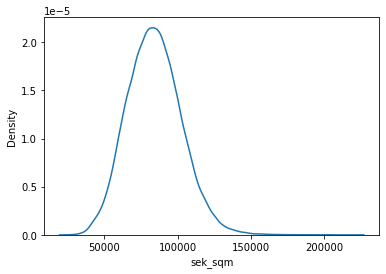

In [12]:
sns.kdeplot(df.sek_sqm)

## sample

In [13]:
sample = df.sek_sqm.sample(2000)

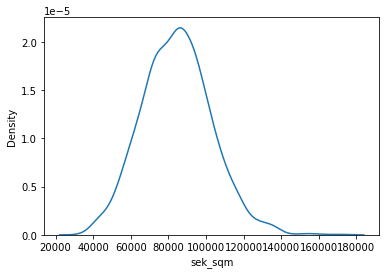

In [14]:
sns.kdeplot(sample)

## How many apartments sold for more than 1 standard deviation of the mean price? 

- What is the expected percentage?
- Calculate the percentage in your simulated data

In [15]:
sample.mean()

84544.441

In [16]:
sample.std()

18467.614086327976

In [17]:
plus_1std = sample.mean() + sample.std()

In [18]:
len([i for i in sample if i > plus_1std]) / len(sample)

0.15

## Standardize the data

- Calculate mean of the standardized data
- Calculate standard deviation of the standardized data
- Visualize the standardized data

In [19]:
import numpy as np

In [20]:
sample_z = pd.array([((i-sample.mean())/sample.std()) for i in sample])

In [21]:
np.set_printoptions(suppress = True, precision = 2)

In [22]:
np.mean(sample_z)

-3.078648447285559e-16

In [23]:
np.array((sample_z)).std()

0.9997499687421855

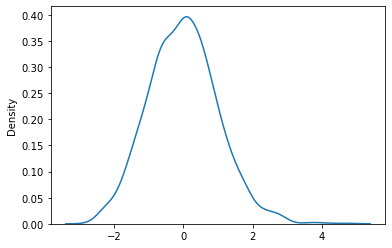

In [24]:
sns.kdeplot(sample_z)
plt.show()

## How many observations has a z-value higher than 1.64? 

- How many percent of the values would have a z-value higher than 1.64 if the data was perfectly normally distributed?
- Calculate the percentage in your data.

In [25]:
# ~5% if perfectly normally distributed

In [26]:
len([i for i in sample_z if i > 1.64]) / len(sample)

0.0535

## Dice CLT

Throw a dice 30 times, calculate and append the mean value to a list. Repeat 1000 times. Visualize the distribution of the 1000 mean values.

In [48]:
dice = [1,2,3,4,5,6]

In [28]:
# 1000 samples with 30 throws

sample_means = []
no_of_throws = 30

for i in range(1000):
    temp_sample = []
    
    for j in range(no_of_throws):
        temp_sample.append(random.choice(dice))
    
    # calculating and appending mean of 1 sample with n no. of throws
    sample_means.append(np.array(temp_sample).mean())
len(sample_means)

1000

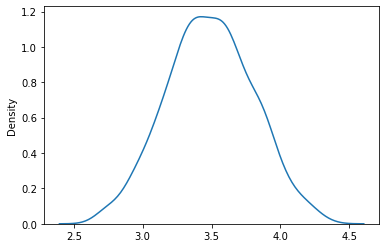

In [29]:
sns.kdeplot(sample_means)

# Lab finished
___

# Bonus challenge

## Q1. Fake dice 30 n per sample

The variable `fake_dice` has another 6 instead of a 1. 

Draw 1000 sample means with 30 throws per round from the "fake_dice". 

1) Visualize the distribution of sample means from the fake_dice and the "true dice" (from the previous question) in the same plot

2) Calculate the SE for both dice 

3) Take the mean +- 1.96 SE to calculate the ~95% range of the sample means for both dice


In [56]:
fake_dice = [6,2,3,4,5,6]

## 1

In [57]:
# TRUE
# 1000 samples with 30 throws
dice = [1,2,3,4,5,6]
sample_means = []
no_of_throws = 30

for i in range(1000):
    temp_sample = []
    
    for j in range(no_of_throws):
        temp_sample.append(random.choice(dice))
    
    # calculating and appending mean of 1 sample with n no. of throws
    sample_means.append(np.array(temp_sample).mean())
len(sample_means)

1000

In [58]:
# 1000 samples with 30 throws
fake_dice = [6,2,3,4,5,6]

sample_means_fake = []
no_of_throws = 30

for i in range(1000):
    temp_sample = []
    
    for j in range(no_of_throws):
        temp_sample.append(random.choice(fake_dice))
    
    # calculating and appending mean of 1 sample with n no. of throws
    sample_means_fake.append(np.array(temp_sample).mean())
len(sample_means_fake)

1000

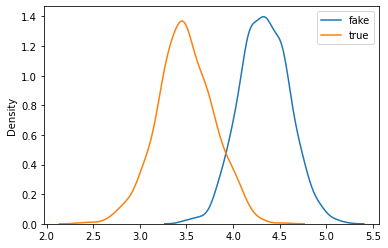

In [59]:
sns.kdeplot(sample_means_fake, label = "fake")
sns.kdeplot(sample_means, label = "true")
plt.legend()
plt.show()

## 2

In [72]:
# SE true dice
se_dice = np.std(dice) / np.sqrt(30)

In [74]:
# SE fake dice
se_fake_dice = np.std(fake_dice) / np.sqrt(30)

## 3

In [85]:
min_fence = np.mean(sample_means) - 1.96*se_dice
max_fence = np.mean(sample_means) + 1.96*se_dice

In [76]:
print(np.mean(sample_means) - 1.96*se_dice,"-", np.mean(sample_means) + 1.96*se_dice)

2.877062626826923 - 4.099337373173077


In [89]:
# verifying
len([i for i in sample_means if min_fence<i<max_fence]) / len(sample_means)

0.952

## 4

In [78]:
print(np.mean(sample_means_fake) - 1.96*se_fake_dice,"-", np.mean(sample_means_fake) + 1.96*se_fake_dice)

3.800355567127219 - 4.867244432872781


## Bonus

In [84]:
(pd.Series(sample_means_fake) > pd.Series(sample_means)).mean()

0.986